# toc words: temporal order coverage

[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/espg/mortie/HEAD?labpath=examples%2Ftoc_temporal_coverage.ipynb)

`mortie` packs a HEALPix cell into one unsigned 64-bit *morton index* that
self-encodes its order and ancestry. The **toc word** — *temporal order
coverage* — is the same trick for time: one `uint64` holding **either** an
exact nanosecond timestamp **or** a quantized, conservative time range, a
tagged union that sorts as a plain unsigned integer and is closed under a
merge that is exactly associative, commutative and idempotent.

```
[start: 32 bits, 2^31 ns units][flag: 1 bit][low: 31 bits]

  timestamp (flag = 1): the word is t_ns with the flag bit spliced in at 31
  range     (flag = 0): low is the end code, 31 bits at 2^32 ns;
                        envelope [start * 2^31, end * 2^32) is half-open
```

That is the whole type. Everything below follows from it: encoding
(`time2toc` / `span2toc`), the dual behaviour under merge (`toc_merge` /
`toc_reduce`), sorting with no comparator, window predicates
(`toc_overlaps` / `toc_contains`), and the UTC/GPS boundary
(`from_datetime64` / `from_gps_ns`).

Layout, epoch, merge results and sort order are **normative** — words persist
on disk — and are pinned by golden fixtures; the decision ledger is
[#175](https://github.com/espg/mortie/issues/175) and the design record is
[englacial/zagg#410](https://github.com/englacial/zagg/issues/410). This is
deliberately **not** an IVOA T-MOC (different epoch, timescale and cell
model). The interval-set algebra over many words is deferred to
[#177](https://github.com/espg/mortie/issues/177).

All data here is synthetic — nothing is downloaded — so the notebook is
[runnable on Binder](https://mybinder.org/v2/gh/espg/mortie/HEAD?labpath=examples%2Ftoc_temporal_coverage.ipynb) as-is (see `binder/` for the
repo2docker config). The only third-party imports are `numpy`, `matplotlib`
and `mortie` itself.


In [1]:
import functools

import numpy as np
import matplotlib.pyplot as plt
import mortie

mortie.__version__


'0.9.7'

## The internal timescale

Internal times are `uint64` **nanoseconds since 1850-01-01T00:00:00** on a
continuous, leap-free, GPS-aligned scale. Leap seconds exist in exactly one
place — the UTC boundary (`from_datetime64` / `to_datetime64`); GPS interop
(`from_gps_ns` / `to_gps_ns`) is a pure constant offset.

Three constants set the type's resolution and reach:

| constant | value | meaning |
|---|---|---|
| `Q_START_NS` | 2^31 ns | a range's start code **floors** to this grid |
| `Q_END_NS`   | 2^32 ns | a range's end code **ceils** to this grid |
| `TOC_MAX_NS` | 2^63 − 2^32 ns | exclusive ceiling on internal times |


In [2]:
print(f'Q_START_NS = {mortie.Q_START_NS:>21,} ns  ({mortie.Q_START_NS / 1e9:.3f} s)')
print(f'Q_END_NS   = {mortie.Q_END_NS:>21,} ns  ({mortie.Q_END_NS / 1e9:.3f} s)')
print(f'TOC_MAX_NS = {mortie.TOC_MAX_NS:>21,} ns  (ceiling '
      f'{mortie.to_datetime64(mortie.TOC_MAX_NS - 1)})')

# The epoch identity: 1850-01-01T00:00:00 UTC is internal ns 0, exactly.
assert mortie.from_datetime64('1850-01-01T00:00:00') == 0


Q_START_NS =         2,147,483,648 ns  (2.147 s)
Q_END_NS   =         4,294,967,296 ns  (4.295 s)
TOC_MAX_NS = 9,223,372,032,559,808,512 ns  (ceiling 2142-04-11T23:46:54.559808511)


## 1. Encoding instants — `time2toc`

A timestamp word is the instant itself with a `1` flag bit spliced in at
position 31, so unsigned word order over timestamps *is* nanosecond order.
`toc_is_range` reads the flag back.


In [3]:
utc = np.array(['2018-01-01T00:00:00', '2018-01-01T00:00:01',
                '2018-06-15T12:34:56.789', '2020-02-29T23:59:59'],
               dtype='datetime64[ns]')

t_ns = mortie.from_datetime64(utc)        # UTC -> internal ns (leap table)
words = mortie.time2toc(t_ns)             # internal ns -> toc words

for u, t, w in zip(utc, t_ns, words):
    print(f'{str(u):<27} {int(t):>21,} ns   0x{int(w):016X}')

print()
print('is_range:', mortie.toc_is_range(words))


2018-01-01T00:00:00.000000000 5,301,590,418,000,000,000 ns   0x932610CAE9813400
2018-01-01T00:00:01.000000000 5,301,590,419,000,000,000 ns   0x932610CBA51BFE00
2018-06-15T12:34:56.789000000 5,315,891,714,789,000,000 ns   0x938BAEB38C70C340
2020-02-29T23:59:59.000000000 5,369,846,417,000,000,000 ns   0x950B0DBB97B06A00

is_range: [False False False False]


The first row is one of the type's **golden fixtures** (pinned in the test
suite and in [PR #178](https://github.com/espg/mortie/pull/178)):
2018-01-01T00:00:00 UTC is internal ns 5,301,590,418,000,000,000 — 61,361 days
of 86,400 s plus the 18 s GPS−UTC offset in force since 2017 — encoding to
`0x932610CAE9813400`.


In [4]:
assert int(mortie.from_datetime64('2018-01-01T00:00:00')) == 5_301_590_418_000_000_000
assert int(mortie.time2toc(5_301_590_418_000_000_000)) == 0x932610CAE9813400
print('golden fixture holds')


golden fixture holds


### The GPS path

Mission time usually arrives as GPS seconds, not UTC. ICESat-2 ATL03, for
instance, stores a per-photon `delta_time` in seconds against the granule's
`atlas_sdp_gps_epoch` (itself GPS seconds since 1980-01-06). Both scales are
leap-free and tick together, so the composition is a constant offset and no
leap table is consulted:

```
gps_ns = epoch_ns + round(delta_time * 1e9)
t_ns   = mortie.from_gps_ns(gps_ns)
```

Add the epoch in **integer** nanoseconds, not in float seconds: `float64` has
53 bits of mantissa, and GPS-epoch-scale ns need ~61, so
`(epoch + delta) * 1e9` quietly loses hundreds of nanoseconds. The type is
exact to 1 ns — don't spend that on the ingest arithmetic.


In [5]:
# ICESat-2 flavored: the ATLAS SDP epoch is GPS second 1_198_800_018
# (= 2018-01-01T00:00:00 UTC), with delta_time seconds off it.
atlas_sdp_gps_epoch = 1_198_800_018
delta_time = np.array([0.0, 0.5, 1.25, 900.0])          # seconds

gps_ns = (atlas_sdp_gps_epoch * 10**9
          + np.round(delta_time * 1e9).astype(np.int64)).astype(np.uint64)
photon_ns = mortie.from_gps_ns(gps_ns)
photon_words = mortie.time2toc(photon_ns)

for d, w, back in zip(delta_time, photon_words,
                      mortie.to_datetime64(photon_ns)):
    print(f'delta_time {d:>8.2f} s   0x{int(w):016X}   {back}')

# The GPS leg agrees with the UTC leg at the shared instant.
assert int(photon_ns[0]) == int(mortie.from_datetime64('2018-01-01T00:00:00'))


delta_time     0.00 s   0x932610CAE9813400   2018-01-01T00:00:00.000000000
delta_time     0.50 s   0x932610CB874E9900   2018-01-01T00:00:00.500000000
delta_time     1.25 s   0x932610CBB402B080   2018-01-01T00:00:01.250000000
delta_time   900.00 s   0x9326126DF5AF5C00   2018-01-01T00:15:00.000000000


## 2. The dual type — exact leaves, conservative ranges

`span2toc` encodes a real closed interval `[start, end]` as a **range** word.
Rounding is outward, with a strictly-greater end ceiling
(`e = (end >> 32) + 1`, uniformly — including when `end` sits exactly on the
2^32 grid), so the decoded envelope always *properly contains* the real
interval. `toc2time` hands back that envelope, with `end_ns` **exclusive**.


In [6]:
seg_start = int(mortie.from_datetime64('2018-06-15T12:00:00'))
seg_end = int(mortie.from_datetime64('2018-06-15T12:05:00'))

seg = mortie.span2toc(seg_start, seg_end)
env_start, env_end = mortie.toc2time(seg)

print(f'word          0x{seg:016X}   is_range={mortie.toc_is_range(seg)}')
print(f'real          [{seg_start:,} .. {seg_end:,}]')
print(f'envelope      [{env_start:,} .. {env_end:,})')
print(f'slack         start {(seg_start - env_start) / 1e9:.3f} s  '
      f'(< {mortie.Q_START_NS / 1e9:.3f} s)   '
      f'end {(env_end - seg_end) / 1e9:.3f} s  '
      f'(<= {mortie.Q_END_NS / 1e9:.3f} s)')

assert env_start <= seg_start and env_end > seg_end


word          0x938BAAE249C5D5B8   is_range=True
real          [5,315,889,618,000,000,000 .. 5,315,889,918,000,000,000]
envelope      [5,315,889,616,488,759,296 .. 5,315,889,921,431,437,312)
slack         start 1.511 s  (< 2.147 s)   end 3.431 s  (<= 4.295 s)


The bound is absolute, not relative: **at most one 2^31 ns quantum of slack at
the start and one 2^32 ns quantum at the end**, whatever the span's length.
Against a five-minute segment that is a fraction of a percent; against the
day-scale spans that merges produce (below) it is noise.


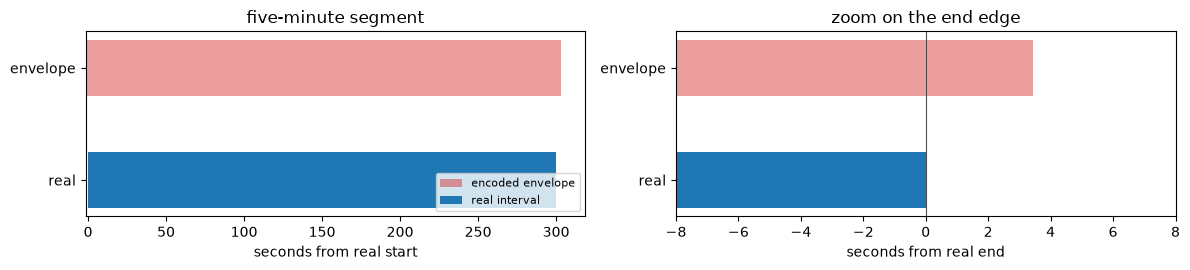

In [7]:
fig, (full, zoom) = plt.subplots(1, 2, figsize=(12, 2.8))


def draw_pair(ax, real, envelope, ref, title, xlabel):
    (r0, r1), (e0, e1) = real, envelope
    ax.barh(1, (e1 - e0) / 1e9, left=(e0 - ref) / 1e9, height=0.5,
            color='#d62728', alpha=0.45, label='encoded envelope')
    ax.barh(0, (r1 - r0) / 1e9, left=(r0 - ref) / 1e9, height=0.5,
            color='#1f77b4', label='real interval')
    ax.set_yticks([0, 1]); ax.set_yticklabels(['real', 'envelope'])
    ax.set_title(title); ax.set_xlabel(xlabel)


draw_pair(full, (seg_start, seg_end), (env_start, env_end), seg_start,
          'five-minute segment', 'seconds from real start')
draw_pair(zoom, (seg_start, seg_end), (env_start, env_end), seg_end,
          'zoom on the end edge', 'seconds from real end')
zoom.set_xlim(-8, 8); zoom.axvline(0, color='0.3', lw=0.8)
full.legend(loc='lower right', fontsize=8)
fig.tight_layout(); plt.show()


### Merge: where the dual type earns its keep

Exact timestamps are the leaves. `toc_merge` (pairwise) and `toc_reduce`
(whole array) join words into the conservative range that covers them — the
semilattice join. Merging is how a granule of a million photon times collapses
to **one** word that a coarse index can hold.


In [8]:
rng = np.random.default_rng(0)

# A synthetic granule: 200k instants scattered over ~6 hours of one day.
day0 = int(mortie.from_datetime64('2018-06-15T00:00:00'))
granule_ns = day0 + np.sort(rng.integers(0, 6 * 3600 * 10**9, size=200_000))
granule = mortie.time2toc(granule_ns.astype(np.uint64))

summary = mortie.toc_reduce(granule)
lo, hi = mortie.toc2time(summary)
true_lo, true_hi = int(granule_ns.min()), int(granule_ns.max())
span_s = (true_hi - true_lo) / 1e9

print(f'{granule.size:,} timestamp words  ->  one word 0x{summary:016X} '
      f'(is_range={mortie.toc_is_range(summary)})')
print(f'true span     {span_s:,.3f} s')
print(f'envelope      {(hi - lo) / 1e9:,.3f} s')
print(f'slack         start {(true_lo - lo) / 1e9:.3f} s, '
      f'end {(hi - true_hi) / 1e9:.3f} s  '
      f'-> {100 * ((hi - lo) - (true_hi - true_lo)) / (true_hi - true_lo):.5f}% wide')


200,000 timestamp words  ->  one word 0x938B5C4E49C5C1CD (is_range=True)
true span     21,599.915 s
envelope      21,603.685 s
slack         start 0.307 s, end 3.463 s  -> 0.01745% wide


Two laws make that reduction safe to run anywhere — in parallel, out of order,
or over already-merged partials:

- **Idempotence.** `toc_merge(w, w) == w` for *any* word: bitwise-equal inputs
  return unchanged, so two equal timestamps never decay into a range.
- **Associativity + commutativity.** Every fold tree over the same words
  yields the identical `uint64`, so a merged summary of merged summaries is
  the same word as one flat reduce.


In [9]:
w0 = int(granule[0])
assert mortie.toc_merge(w0, w0) == w0                     # idempotent
assert mortie.toc_merge(summary, summary) == summary

# fold-tree independence: shuffled left fold == flat reduce == reduce of
# per-chunk partial merges
shuffled = rng.permutation(granule)
left_fold = functools.reduce(mortie.toc_merge, (int(w) for w in shuffled[:5000]))
assert left_fold == mortie.toc_reduce(shuffled[:5000])

chunks = np.array([mortie.toc_reduce(c) for c in np.array_split(granule, 7)],
                  dtype=np.uint64)
assert mortie.toc_reduce(chunks) == summary
print('idempotent, associative, commutative -- all fold trees agree')


idempotent, associative, commutative -- all fold trees agree


## 3. Sorting — one `np.sort`, no comparator

Timestamps and ranges live in the same array and sort together with plain
unsigned `np.sort`: word order is order by conservative encoded start. Within
a tied start quantum, ranges sort before timestamps, then timestamps by exact
ns and ranges shorter-first. Nothing has to know which variant a word is.


In [10]:
base = int(mortie.from_datetime64('2018-06-15T09:00:00'))
minute = 60 * 10**9

mixed = np.concatenate([
    mortie.time2toc(np.array([base + 3 * minute, base + 40 * minute,
                              base + 12 * minute], dtype=np.uint64)),
    mortie.span2toc(np.array([base + 5 * minute, base + 30 * minute],
                             dtype=np.uint64),
                    np.array([base + 9 * minute, base + 35 * minute],
                             dtype=np.uint64)),
])

ordered = np.sort(mixed)                    # that is the entire sort
starts, ends = mortie.toc2time(ordered)
is_range = mortie.toc_is_range(ordered)

print(f'{"word":>18}  {"kind":<9} {"start (UTC)":<27} end')
for w, s, e, r in zip(ordered, starts, ends, is_range):
    kind = 'range' if r else 'timestamp'
    end = str(mortie.to_datetime64(int(e))) if r else '-'
    print(f'0x{int(w):016X}  {kind:<9} '
          f'{str(mortie.to_datetime64(int(s))):<27} {end}')

assert np.all(starts[:-1] <= starts[1:])    # chronological interleave


              word  kind      start (UTC)                 end
0x938B9791B0BFDC00  timestamp 2018-06-15T09:03:00.000000000 -
0x938B97C949C5CC1D  range     2018-06-15T09:04:59.441204224 2018-06-15T09:09:02.106856448
0x938B988CEB41F400  timestamp 2018-06-15T09:12:00.000000000 -
0x938B9A8349C5CD88  range     2018-06-15T09:29:58.384790528 2018-06-15T09:35:01.179984896
0x938B9B9B930F9400  timestamp 2018-06-15T09:40:00.000000000 -


## 4. Window queries — `toc_overlaps` and `toc_contains`

Both predicates run on each word's **conservative encoded bounds** against a
half-open window `[q_start_ns, q_end_ns)`. That fixes their error direction,
and the direction is the useful one:

- `toc_overlaps` **never under-reports** — every word whose real time content
  meets the window tests `True` — but may over-report by up to one quantum.
  It is a safe *candidate filter*: refine survivors against exact times.
- `toc_contains` **never over-reports** — envelope-inside-window implies
  interval-inside-window — but may under-report by up to one quantum. It is a
  safe *certainty filter*.


In [11]:
q_start = base + 4 * minute
q_end = base + 31 * minute

hits = mortie.toc_overlaps(ordered, q_start, q_end)
inside = mortie.toc_contains(ordered, q_start, q_end)

print(f'window [{mortie.to_datetime64(q_start)} .. '
      f'{mortie.to_datetime64(q_end)})\n')
for w, r, h, c in zip(ordered, is_range, hits, inside):
    print(f'0x{int(w):016X}  {"range" if r else "timestamp":<9} '
          f'overlaps={bool(h)!s:<5} contains={bool(c)!s}')


window [2018-06-15T09:04:00.000000000 .. 2018-06-15T09:31:00.000000000)

0x938B9791B0BFDC00  timestamp overlaps=False contains=False
0x938B97C949C5CC1D  range     overlaps=True  contains=True
0x938B988CEB41F400  timestamp overlaps=True  contains=True
0x938B9A8349C5CD88  range     overlaps=True  contains=False
0x938B9B9B930F9400  timestamp overlaps=False contains=False


### Seeing the quantum at a window edge

Both edge behaviours are constructible on purpose. The snapping below is what
makes them *reproducible* rather than lucky: whether a given window edge shows
the quantum depends on where it falls against the grid, so `q_start` is floored
onto the 2^31 grid and `q_end` is put one nanosecond past a 2^32 grid line.
Then:

1. a range whose real interval ends *just inside* the window still has its
   envelope end ceil past `q_end`, so `contains` is `False` (under-report);
2. a range whose real interval ends *just before* the window has its envelope
   end ceil past `q_start`, so `overlaps` is `True` (over-report).


In [12]:
qs = (base // mortie.Q_START_NS) * mortie.Q_START_NS               # 2^31-aligned
grid = ((qs + 3600 * 10**9) // mortie.Q_END_NS) * mortie.Q_END_NS  # a 2^32 grid line
qe = grid + 1                                                # 1 ns past it

# (1) real interval inside the window, envelope end spills past qe
a = mortie.span2toc(qs + minute, grid)
# (2) real interval entirely before the window, envelope end spills past qs
b = mortie.span2toc(qs - 10 * 10**9, qs - 1)

print(f'window   [{qs:,} .. {qe:,})\n')
for name, w in [('inside-but-not-contained', a), ('before-but-overlapping', b)]:
    s, e = mortie.toc2time(w)
    print(f'{name:<26} envelope [{s:,} .. {e:,})  '
          f'overlaps={mortie.toc_overlaps(w, qs, qe)!s:<5} '
          f'contains={mortie.toc_contains(w, qs, qe)}')

assert mortie.toc_overlaps(a, qs, qe) and not mortie.toc_contains(a, qs, qe)
assert mortie.toc_overlaps(b, qs, qe)
print(f'\nboth errors are bounded by one quantum: '
      f'{mortie.Q_END_NS / 1e9:.3f} s')


window   [5,315,878,816,793,493,504 .. 5,315,882,413,828,603,905)

inside-but-not-contained   envelope [5,315,878,874,775,552,000 .. 5,315,882,418,123,571,200)  overlaps=True  contains=False
before-but-overlapping     envelope [5,315,878,806,056,075,264 .. 5,315,878,818,940,977,152)  overlaps=True  contains=False

both errors are bounded by one quantum: 4.295 s


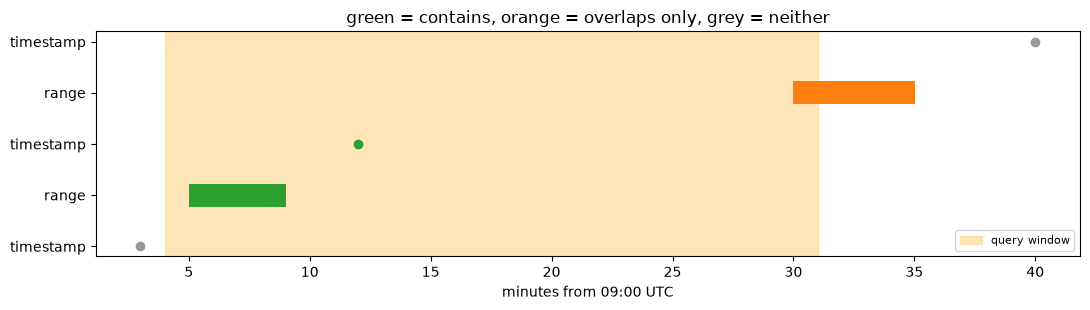

In [13]:
fig, ax = plt.subplots(figsize=(11, 3.2))
ref = base
ax.axvspan((q_start - ref) / 1e9 / 60, (q_end - ref) / 1e9 / 60,
           color='#ffd27f', alpha=0.55, label='query window')

for row, (w, s, e, r, h, c) in enumerate(
        zip(ordered, starts, ends, is_range, hits, inside)):
    color = '#2ca02c' if c else ('#ff7f0e' if h else '#999999')
    if r:
        ax.barh(row, (int(e) - int(s)) / 1e9 / 60, left=(int(s) - ref) / 1e9 / 60,
                height=0.45, color=color)
    else:
        ax.plot((int(s) - ref) / 1e9 / 60, row, 'o', color=color)

ax.set_yticks(range(len(ordered)))
ax.set_yticklabels(['range' if r else 'timestamp' for r in is_range])
ax.set_xlabel('minutes from 09:00 UTC')
ax.set_title('green = contains, orange = overlaps only, grey = neither')
ax.legend(loc='lower right', fontsize=8)
fig.tight_layout(); plt.show()


## 5. Round-trip, and where leap seconds live

`toc2time` → `to_datetime64` closes the loop. A timestamp round-trips
**exactly** (it decodes to `(t, t)`); a range round-trips to its envelope,
which is the conservative answer by construction.


In [14]:
rt_start, rt_end = mortie.toc2time(words)
assert np.array_equal(rt_start, t_ns) and np.array_equal(rt_end, t_ns)
assert np.array_equal(mortie.to_datetime64(rt_start), utc)
print('timestamps round-trip exactly through the toc word')

lo_dt, hi_dt = mortie.to_datetime64(lo), mortie.to_datetime64(hi)
print(f'merged granule envelope: [{lo_dt} .. {hi_dt})')


timestamps round-trip exactly through the toc word
merged granule envelope: [2018-06-14T23:59:59.707696128 .. 2018-06-15T06:00:03.393195008)


Leap seconds are confined to the UTC boundary. The internal scale is
continuous, so an inserted leap second shows up as a **two-second** internal
gap across a UTC step that looks like one second — that is the leap second
being counted, exactly once, in the right place.


In [15]:
before = int(mortie.from_datetime64('2016-12-31T23:59:59'))
after = int(mortie.from_datetime64('2017-01-01T00:00:00'))
print(f'UTC step of 1 s  ->  internal step of {(after - before) / 1e9:.0f} s '
      '(the 2016-12-31 leap second)')

# datetime64 cannot name 23:59:60, so an instant *inside* the leap second
# renders into the following UTC second -- documented, and one-way.
mid = before + 1_500_000_000
print(f'mid-leap-second internal instant renders as {mortie.to_datetime64(mid)}')


UTC step of 1 s  ->  internal step of 2 s (the 2016-12-31 leap second)
mid-leap-second internal instant renders as 2017-01-01T00:00:00.500000000


## Notes

- **The API is flat on the package.** `mortie.time2toc`, `span2toc`,
  `toc2time`, `toc_merge`, `toc_reduce`, `toc_is_range`, `toc_overlaps`,
  `toc_contains`, `from_datetime64`, `to_datetime64`, `from_gps_ns`,
  `to_gps_ns`; the constants live flat on the package (`mortie.Q_START_NS`,
  `Q_END_NS`, `TOC_MAX_NS`, `GPS_EPOCH_NS`). Rendered reference:
  [docs/api/toc.md](../docs/api/toc.md).
- **Range ends are exclusive.** `toc2time` returns a half-open envelope; a
  timestamp returns `(t, t)`, the one closed case.
- **Ceiling.** Both encoders reject times at or past `TOC_MAX_NS`
  (~4.3 s short of the year-2142 span ceiling) so that every encodable word is
  mergeable — a timestamp in that final window would overflow the end field on
  its first merge.
- **Pre-1972 UTC** uses a zero-offset proleptic convention (naive day-count
  seconds), which is what pins the epoch identity
  `from_datetime64('1850-01-01') == 0`; conversion is exact and invertible
  from 1972 on. See the `from_datetime64` docstring.
- **Not an IVOA T-MOC**, and the interval-set algebra over collections of
  words (unions of disjoint ranges, ragged per-cell temporal covers) is
  deferred to [#177](https://github.com/espg/mortie/issues/177) — this
  notebook is the flat-array elementwise surface only.
